## Verifying correctness of variational equation

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from heston.tree import HestonTreeFast
from heston.closed import HestonClosed

In [2]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

option_type = "put"

n = 100
mv = 3 * n
mz = 6 * n
V0_min = 0.01
V0_max = 0.3
S0_min = S0 * 0.5
S0_max = S0 * 1.5

tree = HestonTreeFast(n, mz, mv, K, T, r, kappa, theta, sigma, rho)
tree.build_tree(V0_min, V0_max, S0_min, S0_max, option_type=option_type, exercise_type='european')

closed = HestonClosed(K, r, T, kappa, theta, sigma, rho)

dt = tree.dt


In [3]:
dS = 1e-6
dV = 1e-6

model = closed

# Grid
resolution = 40
S_vals = np.linspace(S0_min + dS, S0_max - dS, resolution)
V_vals = np.linspace(V0_min + dV, V0_max - dV, resolution)

residual_grid = np.zeros((len(V_vals), len(S_vals)))

ut_grid = np.zeros_like(residual_grid)
Lu_grid = np.zeros_like(residual_grid)
ru_grid = np.zeros_like(residual_grid)

for i, V in enumerate(V_vals):
    for j, S in enumerate(S_vals):
        u = model.price(V, S)

        if isinstance(model, HestonTreeFast):
            u_forward = model.price(V, S, k=1)
            u_t = (u_forward - u) / dt  # backward time derivative
        else:
            u_forward = model.price(V, S, t=1e-6)
            u_t = (u_forward - u) / 1e-6

        u_S = (model.price(V, S + dS) - model.price(V, S - dS)) / (2*dS)
        u_V = (model.price(V + dV, S) - model.price(V - dV, S)) / (2*dV)

        u_SS = (model.price(V, S + dS) - 2*u + model.price(V, S - dS)) / (dS**2)
        u_VV = (model.price(V + dV, S) - 2*u + model.price(V - dV, S)) / (dV**2)

        u_SV = (
            model.price(V + dV, S + dS)
            - model.price(V + dV, S - dS)
            - model.price(V - dV, S + dS)
            + model.price(V - dV, S - dS)
        ) / (4*dS*dV)

        Lu = (
            r * S * u_S
            + kappa * (theta - V) * u_V
            + 0.5 * (
                S**2 * V * u_SS
                + 2 * rho *sigma * S * V * u_SV
                + sigma**2 * V * u_VV
            )
        )

        ut_grid[i, j] = u_t
        Lu_grid[i, j] = Lu
        ru_grid[i, j] = r * u

        residual_grid[i, j] = r * u - u_t + Lu


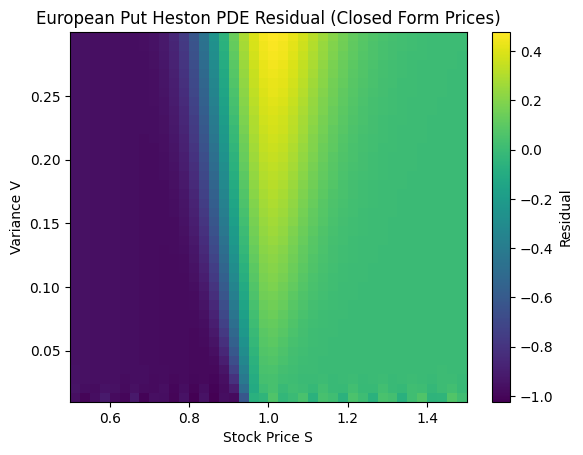

In [4]:
# Single heatmap
plt.figure()
plt.imshow(residual_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("European Put Heston PDE Residual (Closed Form Prices)")
plt.colorbar(label="Residual")
plt.show()

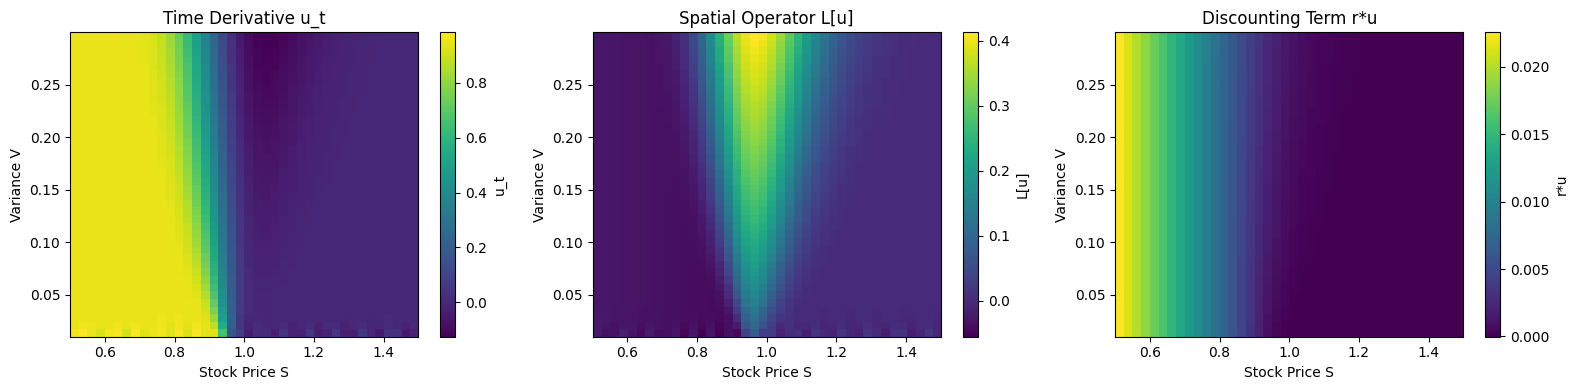

In [5]:
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1)
plt.imshow(ut_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Time Derivative u_t")
plt.colorbar(label="u_t")

plt.subplot(1, 3, 2)
plt.imshow(Lu_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Spatial Operator L[u]")
plt.colorbar(label="L[u]")

plt.subplot(1, 3, 3)
plt.imshow(ru_grid, aspect='auto',
           extent=[S_vals.min(), S_vals.max(), V_vals.min(), V_vals.max()],
           origin='lower')
plt.xlabel("Stock Price S")
plt.ylabel("Variance V")
plt.title("Discounting Term r*u")
plt.colorbar(label="r*u")

plt.tight_layout()
plt.show()